In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# external imports
from pathlib import Path
import os
from dotenv import load_dotenv
from torch_geometric.data import Batch
import torch
import random

In [3]:
# internal imports
from primaite.network.generator import NetworkGenerator
from primaite.agents.aegis.modules.openai import OpenAIClient

2024-09-11 16:04:07.307262: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-11 16:04:07.354934: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-11 16:04:08.034764: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jonathan/projects/primaite/PrimAITE/aegis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jonathan/projects/primaite/PrimAITE/aegis/lib/python3.10/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_id" has 

In [4]:
# constants
DATASET_SIZE = 100
CORPUS_GRAPH_SIZES = [5, 10, 20, 40]
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]

In [5]:
load_dotenv() 
open_ai_key = os.getenv('OPEN_AI_KEY')

openai = OpenAIClient(api_key=open_ai_key)

2024-09-11 16:04:13,541: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-11 16:04:13,565: Environment configuration loaded
2024-09-11 16:04:13,679: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7fb904cfa080> observation component
2024-09-11 16:04:13,681: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-11 16:04:13,682: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-11/2024-09-11_16-04-13


{'end_step': 117, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '3', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'GOOD', 'start_step': 106, 'state': 'GOOD', 'targetNodeId': '3', 'type': 'OS'}
{'end_step': 27, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '1', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 14, 'state': 'COMPROMISED', 'targetNodeId': '1', 'type': 'SERVICE'}
{'end_step': 120, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '3', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'NONE', 'start_step': 120, 'state': 'NONE', 'targetNodeId': '3', 'type': 'SERVICE'}
{'end_step': 67, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'NONE', 'start

2024-09-11 16:04:16,587: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-11 16:04:16,611: Environment configuration loaded
2024-09-11 16:04:16,711: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7fb904b5d360> observation component
2024-09-11 16:04:16,712: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-11 16:04:16,713: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-11/2024-09-11_16-04-16


{'end_step': 117, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '3', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'GOOD', 'start_step': 106, 'state': 'GOOD', 'targetNodeId': '3', 'type': 'OS'}
{'end_step': 27, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '1', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 14, 'state': 'COMPROMISED', 'targetNodeId': '1', 'type': 'SERVICE'}
{'end_step': 120, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '3', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'NONE', 'start_step': 120, 'state': 'NONE', 'targetNodeId': '3', 'type': 'SERVICE'}
{'end_step': 67, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'NONE', 'start

2024-09-11 16:04:16,837: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-11 16:04:16,863: Environment configuration loaded
2024-09-11 16:04:16,992: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7fb904b5c0d0> observation component
2024-09-11 16:04:16,994: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-11 16:04:16,995: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-11/2024-09-11_16-04-16


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

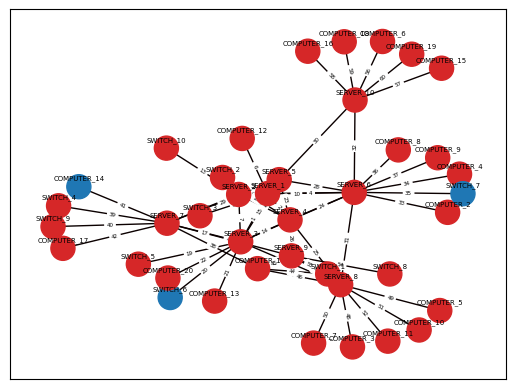

In [6]:
for corpus_graph_size in CORPUS_GRAPH_SIZES:
    corpus = []
    laydown_root_dir = '../data/datasets/notebook_generated_dataset/'
    if not os.path.exists(laydown_root_dir):
        os.mkdir(laydown_root_dir)

    for i in range(DATASET_SIZE // len(CORPUS_GRAPH_SIZES)):
        laydown_save_path = laydown_root_dir + f"{corpus_graph_size}_{i}.yaml"
        generator = NetworkGenerator(graph_size=corpus_graph_size, training_config_path=TRAINING_CONFIG_PATH, random_seed=None, services=SERVICE_NAMES, ports=PORTS_LIST, pretrained_llm=openai)
        output = generator.run_end_to_end(laydown_save_path=laydown_save_path)
        corpus.append(output)

    batch = Batch.from_data_list(corpus)
    torch.save(batch, "../data/datasets/notebook_generated_dataset/dataset.pt")